In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV


from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Big Data Lanjut/Dataset after ubah'
shared_folder_path = '/content/drive/Shared drives/Big Data Lanjut/Dataset after ubah'

Mounted at /content/drive


# 1. Menyatukan Data




In [ ]:
df_tempat_tinggal = pd.read_csv("{}/Tempat_tinggal.csv".format(path))
df_tempat_tinggal

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri
0,ACEH,ACEH BARAT,1177,338,18270
1,ACEH,ACEH BARAT DAYA,2097,570,15359
2,ACEH,ACEH BESAR,3887,971,34134
3,ACEH,ACEH JAYA,684,68,7178
4,ACEH,ACEH SELATAN,3304,766,25008
...,...,...,...,...,...
509,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873
510,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625
511,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690
512,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502


In [ ]:
df_air_minum = pd.read_csv("{}/Air_minum.csv".format(path))
df_air_minum

,Provinsi,NamaKab/Kota,Air Kemasan,Air Ledeng,Sumber Terlindung,Sumber Tidak Terlindung
0,ACEH,ACEH BARAT,1904,313,10073,7652
1,ACEH,ACEH BARAT DAYA,947,347,12419,4360
2,ACEH,ACEH BESAR,11310,2014,21377,4810
3,ACEH,ACEH JAYA,470,219,4923,2340
4,ACEH,ACEH SELATAN,1135,812,16574,10874
...,...,...,...,...,...,...
543,SUMATERA UTARA,TAPANULI SELATAN,106,340,8012,11616
544,SUMATERA UTARA,TAPANULI TENGAH,684,2011,9814,17178
545,SUMATERA UTARA,TAPANULI UTARA,4,1431,15413,9190
546,SUMATERA UTARA,TOBA SAMOSIR,84,240,5378,2724


In [ ]:
df_pendidikan = pd.read_csv("{}/Pendidikan.csv".format(path))
df_pendidikan

,Provinsi,NamaKab/Kota,KodeKab/Kota,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
0,ACEH,ACEH BARAT,1107,16550,2867
1,ACEH,ACEH BARAT DAYA,1112,18151,3445
2,ACEH,ACEH BESAR,1108,37828,5580
3,ACEH,ACEH JAYA,1116,7688,1170
4,ACEH,ACEH SELATAN,1103,27316,4920
...,...,...,...,...,...
509,SUMATERA UTARA,SIMALUNGUN,1209,47650,7579
510,SUMATERA UTARA,TAPANULI SELATAN,1203,22869,4407
511,SUMATERA UTARA,TAPANULI TENGAH,1204,42936,7600
512,SUMATERA UTARA,TAPANULI UTARA,1205,38143,3235


In [ ]:
df_penerangan = pd.read_csv("{}/Penerangan.csv".format(path))
df_penerangan

,Provinsi,NamaKab/Kota,Listrik PLN,Listrik non-PLN,Tidak ada listrik
0,ACEH,ACEH BARAT,18835,125,982
1,ACEH,ACEH BARAT DAYA,17414,125,534
2,ACEH,ACEH BESAR,38484,202,825
3,ACEH,ACEH JAYA,7752,21,179
4,ACEH,ACEH SELATAN,27762,200,1433
...,...,...,...,...,...
543,SUMATERA UTARA,TAPANULI SELATAN,15034,1203,3837
544,SUMATERA UTARA,TAPANULI TENGAH,25424,889,3374
545,SUMATERA UTARA,TAPANULI UTARA,23512,549,1977
546,SUMATERA UTARA,TOBA SAMOSIR,7427,164,835


In [ ]:
df_status_bekerja = pd.read_csv("{}/Status bekerja.csv".format(path))

# Menghapus kolom yang seluruhnya NaN
df_status_bekerja = df_status_bekerja.dropna(how='all')

df_status_bekerja

,Provinsi,NamaKab/Kota,KodeKab/Kota,Bekerja,Tidak Bekerja
1,ACEH,ACEH BARAT,1107.0,31848.0,38077.0
2,ACEH,ACEH BARAT DAYA,1112.0,23497.0,48534.0
3,ACEH,ACEH BESAR,1108.0,51263.0,90972.0
4,ACEH,ACEH JAYA,1116.0,12924.0,15610.0
5,ACEH,ACEH SELATAN,1103.0,35839.0,70932.0
...,...,...,...,...,...
510,SUMATERA UTARA,SIMALUNGUN,1209.0,67939.0,84736.0
511,SUMATERA UTARA,TAPANULI SELATAN,1203.0,35756.0,35060.0
512,SUMATERA UTARA,TAPANULI TENGAH,1204.0,54921.0,65013.0
513,SUMATERA UTARA,TAPANULI UTARA,1205.0,63399.0,37950.0


In [ ]:
df_tempat_bab = pd.read_csv("{}/Tempat_bab.csv".format(path))
df_tempat_bab

,Provinsi,NamaKab/Kota,Jamban Bersama/Umum,Jamban Sendiri,Tidak ada
0,ACEH,ACEH BARAT,1464,8719,9759
1,ACEH,ACEH BARAT DAYA,5215,3087,9771
2,ACEH,ACEH BESAR,6803,24440,8268
3,ACEH,ACEH JAYA,1785,3392,2775
4,ACEH,ACEH SELATAN,2627,9889,16879
...,...,...,...,...,...
509,SUMATERA UTARA,SIMALUNGUN,2838,26606,13166
510,SUMATERA UTARA,TAPANULI SELATAN,12132,2112,5830
511,SUMATERA UTARA,TAPANULI TENGAH,2025,6375,21287
512,SUMATERA UTARA,TAPANULI UTARA,2966,12302,10770


In [ ]:
df_tempat_tinggal = pd.read_csv("{}/Tempat_tinggal.csv".format(path))
df_tempat_tinggal

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri
0,ACEH,ACEH BARAT,1177,338,18270
1,ACEH,ACEH BARAT DAYA,2097,570,15359
2,ACEH,ACEH BESAR,3887,971,34134
3,ACEH,ACEH JAYA,684,68,7178
4,ACEH,ACEH SELATAN,3304,766,25008
...,...,...,...,...,...
509,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873
510,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625
511,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690
512,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502


In [ ]:
# Chain merge operations:
data_final = pd.merge(df_tempat_tinggal, df_penerangan, on=['Provinsi', 'NamaKab/Kota'], how='outer')
data_final = pd.merge(data_final, df_air_minum, on=['Provinsi', 'NamaKab/Kota'], how='outer')
data_final = pd.merge(data_final, df_tempat_bab, on=['Provinsi', 'NamaKab/Kota'], how='outer')
data_final = pd.merge(data_final, df_status_bekerja, on=['Provinsi', 'NamaKab/Kota'], how='outer')
data_final = pd.merge(data_final, df_pendidikan, on=['Provinsi', 'NamaKab/Kota'], how='outer')

# Now, data_final should contain the merged data from all your DataFrames.
data_final

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,...,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak ada,KodeKab/Kota_x,Bekerja,Tidak Bekerja,KodeKab/Kota_y,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
0,ACEH,ACEH BARAT,1177.0,338.0,18270.0,18835,125,982,1904,313,...,7652,1464.0,8719.0,9759.0,1107.0,31848.0,38077.0,1107.0,16550.0,2867.0
1,ACEH,ACEH BARAT DAYA,2097.0,570.0,15359.0,17414,125,534,947,347,...,4360,5215.0,3087.0,9771.0,1112.0,23497.0,48534.0,1112.0,18151.0,3445.0
2,ACEH,ACEH BESAR,3887.0,971.0,34134.0,38484,202,825,11310,2014,...,4810,6803.0,24440.0,8268.0,1108.0,51263.0,90972.0,1108.0,37828.0,5580.0
3,ACEH,ACEH JAYA,684.0,68.0,7178.0,7752,21,179,470,219,...,2340,1785.0,3392.0,2775.0,1116.0,12924.0,15610.0,1116.0,7688.0,1170.0
4,ACEH,ACEH SELATAN,3304.0,766.0,25008.0,27762,200,1433,1135,812,...,10874,2627.0,9889.0,16879.0,1103.0,35839.0,70932.0,1103.0,27316.0,4920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,SUMATERA UTARA,TAPANULI SELATAN,3384.0,2650.0,13625.0,15034,1203,3837,106,340,...,11616,12132.0,2112.0,5830.0,1203.0,35756.0,35060.0,1203.0,22869.0,4407.0
544,SUMATERA UTARA,TAPANULI TENGAH,5383.0,3192.0,20690.0,25424,889,3374,684,2011,...,17178,2025.0,6375.0,21287.0,1204.0,54921.0,65013.0,1204.0,42936.0,7600.0
545,SUMATERA UTARA,TAPANULI UTARA,5561.0,1523.0,17502.0,23512,549,1977,4,1431,...,9190,2966.0,12302.0,10770.0,1205.0,63399.0,37950.0,1205.0,38143.0,3235.0
546,SUMATERA UTARA,TOBA SAMOSIR,2778.0,787.0,4693.0,7427,164,835,84,240,...,2724,576.0,3310.0,4540.0,1206.0,22110.0,15123.0,1206.0,15638.0,1371.0


In [ ]:
print(data_final.columns.tolist())

['Provinsi', 'NamaKab/Kota', 'Bebas Sewa', 'Kontrak/Sewa', 'Milik Sendiri', 'Listrik PLN', 'Listrik non-PLN', 'Tidak ada listrik', 'Air Kemasan', 'Air Ledeng', 'Sumber Terlindung', 'Sumber Tidak Terlindung', 'Jamban Bersama/Umum', 'Jamban Sendiri', 'Tidak ada', 'KodeKab/Kota_x', 'Bekerja', 'Tidak Bekerja', 'KodeKab/Kota_y', 'Jumlah Anak yang Bersekolah', 'Jumlah Anak yang Tidak Bersekolah']


# 2. Data Preprocessing

In [ ]:
print(data_final.dtypes)

Provinsi                              object
NamaKab/Kota                          object
Bebas Sewa                           float64
Kontrak/Sewa                         float64
Milik Sendiri                        float64
Listrik PLN                            int64
Listrik non-PLN                        int64
Tidak ada listrik                      int64
Air Kemasan                            int64
Air Ledeng                             int64
Sumber Terlindung                      int64
Sumber Tidak Terlindung                int64
Jamban Bersama/Umum                  float64
Jamban Sendiri                       float64
Tidak ada                            float64
KodeKab/Kota_x                       float64
Bekerja                              float64
Tidak Bekerja                        float64
KodeKab/Kota_y                       float64
Jumlah Anak yang Bersekolah          float64
Jumlah Anak yang Tidak Bersekolah    float64
dtype: object


In [ ]:
# Mengonversi kolom yang diinginkan menjadi integer
kolom_diubah = ['Bebas Sewa', 'Kontrak/Sewa', 'Milik Sendiri', 'Listrik PLN', 'Listrik non-PLN', 'Tidak ada listrik', 'Air Kemasan', 'Air Ledeng', 'Sumber Terlindung', 'Sumber Tidak Terlindung', 'Jamban Bersama/Umum', 'Jamban Sendiri', 'Tidak ada', 'Bekerja', 'Tidak Bekerja', 'Jumlah Anak yang Bersekolah', 'Jumlah Anak yang Tidak Bersekolah']

# Mengganti data NaN menjadi 0
data_final[kolom_diubah] = data_final[kolom_diubah].fillna(0).astype(int)

# Mengubah tipe data menjadi integer
data_final[kolom_diubah] = data_final[kolom_diubah].astype(int)
data_final = data_final[data_final['NamaKab/Kota'] != 'TOTAL']

# Menampilkan tipe data setelah konversi
print("\nSetelah konversi:")
print(data_final.dtypes)



Setelah konversi:
Provinsi                              object
NamaKab/Kota                          object
Bebas Sewa                             int64
Kontrak/Sewa                           int64
Milik Sendiri                          int64
Listrik PLN                            int64
Listrik non-PLN                        int64
Tidak ada listrik                      int64
Air Kemasan                            int64
Air Ledeng                             int64
Sumber Terlindung                      int64
Sumber Tidak Terlindung                int64
Jamban Bersama/Umum                    int64
Jamban Sendiri                         int64
Tidak ada                              int64
KodeKab/Kota_x                       float64
Bekerja                                int64
Tidak Bekerja                          int64
KodeKab/Kota_y                       float64
Jumlah Anak yang Bersekolah            int64
Jumlah Anak yang Tidak Bersekolah      int64
dtype: object


In [ ]:
data_final.isnull().sum()

,0
Provinsi,0
NamaKab/Kota,0
Bebas Sewa,0
Kontrak/Sewa,0
Milik Sendiri,0
Listrik PLN,0
Listrik non-PLN,0
Tidak ada listrik,0
Air Kemasan,0
Air Ledeng,0


In [ ]:
# Drop kolom kode Kab/Kota
data_final.drop(columns=['KodeKab/Kota_x', 'KodeKab/Kota_y'], inplace=True)

<ipython-input-14-971634a7f92b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final.drop(columns=['KodeKab/Kota_x', 'KodeKab/Kota_y'], inplace=True)


In [ ]:
# Mengganti nama kolom tidak ada menjadi tidak ada jamban
data_final.rename(columns={'Tidak ada': 'Tidak Ada Jamban'}, inplace=True)

<ipython-input-15-898a3880af64>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final.rename(columns={'Tidak ada': 'Tidak Ada Jamban'}, inplace=True)


In [ ]:
data_final

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,Sumber Terlindung,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
0,ACEH,ACEH BARAT,1177,338,18270,18835,125,982,1904,313,10073,7652,1464,8719,9759,31848,38077,16550,2867
1,ACEH,ACEH BARAT DAYA,2097,570,15359,17414,125,534,947,347,12419,4360,5215,3087,9771,23497,48534,18151,3445
2,ACEH,ACEH BESAR,3887,971,34134,38484,202,825,11310,2014,21377,4810,6803,24440,8268,51263,90972,37828,5580
3,ACEH,ACEH JAYA,684,68,7178,7752,21,179,470,219,4923,2340,1785,3392,2775,12924,15610,7688,1170
4,ACEH,ACEH SELATAN,3304,766,25008,27762,200,1433,1135,812,16574,10874,2627,9889,16879,35839,70932,27316,4920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873,40375,417,1818,490,8541,27102,6477,2838,26606,13166,67939,84736,47650,7579
543,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625,15034,1203,3837,106,340,8012,11616,12132,2112,5830,35756,35060,22869,4407
544,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690,25424,889,3374,684,2011,9814,17178,2025,6375,21287,54921,65013,42936,7600
545,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502,23512,549,1977,4,1431,15413,9190,2966,12302,10770,63399,37950,38143,3235


In [ ]:
data_final.columns

Index(['Provinsi', 'NamaKab/Kota', 'Bebas Sewa', 'Kontrak/Sewa',
       'Milik Sendiri', 'Listrik PLN', 'Listrik non-PLN', 'Tidak ada listrik',
       'Air Kemasan', 'Air Ledeng', 'Sumber Terlindung',
       'Sumber Tidak Terlindung', 'Jamban Bersama/Umum', 'Jamban Sendiri',
       'Tidak Ada Jamban', 'Bekerja', 'Tidak Bekerja',
       'Jumlah Anak yang Bersekolah', 'Jumlah Anak yang Tidak Bersekolah'],
      dtype='object')

In [ ]:
# Save to CSV
folder_path = '/content/drive/MyDrive/Big Data Lanjut/Dataset after ubah'
file_name = 'Dataset_final.csv'
file_path = f'{folder_path}/{file_name}'
data_final.to_csv(file_path, index=False)

# 3. Exploratoty Data

In [ ]:
data_final.describe()

,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,Sumber Terlindung,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000
mean,4016.826848,1357.733463,37177.766537,39314.124514,1287.165370,2473.011673,3644.898833,4042.766537,24019.844358,11366.673152,9081.110895,22831.500000,11161.496109,62855.317121,84121.161479,32732.881323,8922.824903
std,5607.152551,3403.281109,50511.489852,56269.621817,2037.824788,4420.001978,9381.118258,7490.396069,37867.417720,15576.584739,16176.685996,30383.089817,18323.136245,74652.653769,111053.881759,36650.129739,12532.789634
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,800.250000,77.000000,8420.000000,7113.750000,180.750000,314.250000,145.000000,303.000000,3075.250000,2379.750000,1516.750000,4225.750000,1911.250000,16214.000000,20760.000000,9925.500000,2310.250000
50%,2080.500000,327.500000,16827.000000,16414.500000,579.500000,1067.000000,666.000000,1243.000000,8150.000000,6435.000000,3250.500000,9764.500000,4988.000000,32240.000000,42553.000000,19562.500000,4785.500000
75%,4760.000000,1138.000000,39382.250000,40154.500000,1489.500000,2804.750000,2895.250000,4339.250000,23406.250000,14242.750000,9222.750000,26047.000000,11853.250000,75699.000000,95933.750000,43266.000000,10139.000000
max,47080.000000,32658.000000,293165.000000,324687.000000,21586.000000,48782.000000,84848.000000,68116.000000,225844.000000,117641.000000,161230.000000,170333.000000,187950.000000,425865.000000,794072.000000,270618.000000,111978.000000


                                   Bebas Sewa  Kontrak/Sewa  Milik Sendiri  \
Bebas Sewa                           1.000000      0.572928       0.702195   
Kontrak/Sewa                         0.572928      1.000000       0.183518   
Milik Sendiri                        0.702195      0.183518       1.000000   
Listrik PLN                          0.786755      0.301987       0.985113   
Listrik non-PLN                      0.044825     -0.012259       0.168966   
Tidak ada listrik                   -0.132935     -0.129493      -0.034623   
Air Kemasan                          0.594759      0.610747       0.431368   
Air Ledeng                           0.630411      0.532909       0.510291   
Sumber Terlindung                    0.698618      0.159029       0.962788   
Sumber Tidak Terlindung              0.450523      0.041858       0.725179   
Jamban Bersama/Umum                  0.736456      0.353024       0.854191   
Jamban Sendiri                       0.784761      0.360706     

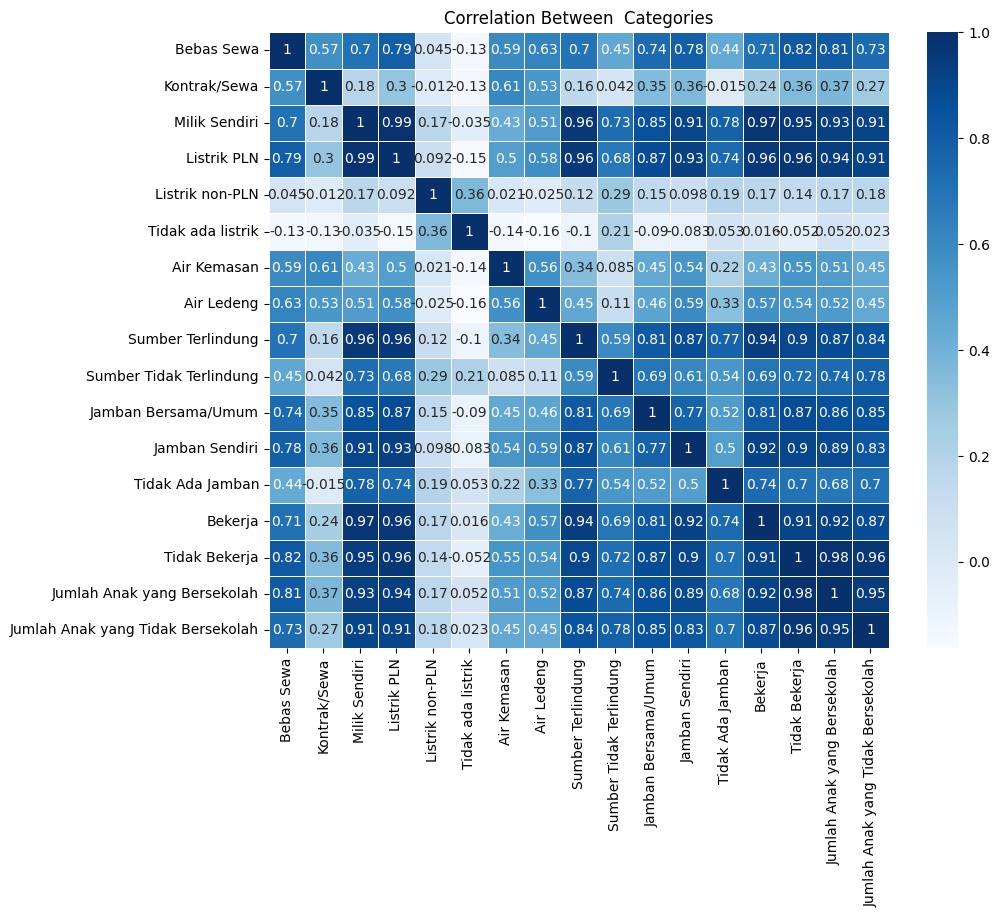

In [ ]:
data_baru = data_final.drop(columns=['Provinsi', 'NamaKab/Kota'])
korelasi = data_baru.corr()
print(korelasi)

# Heatmap for correlation between internet usage columns
plt.figure(figsize=(10, 8))
sns.heatmap(korelasi, annot=True, cmap='Blues', linewidths=0.5)

plt.title('Correlation Between  Categories')
plt.show()


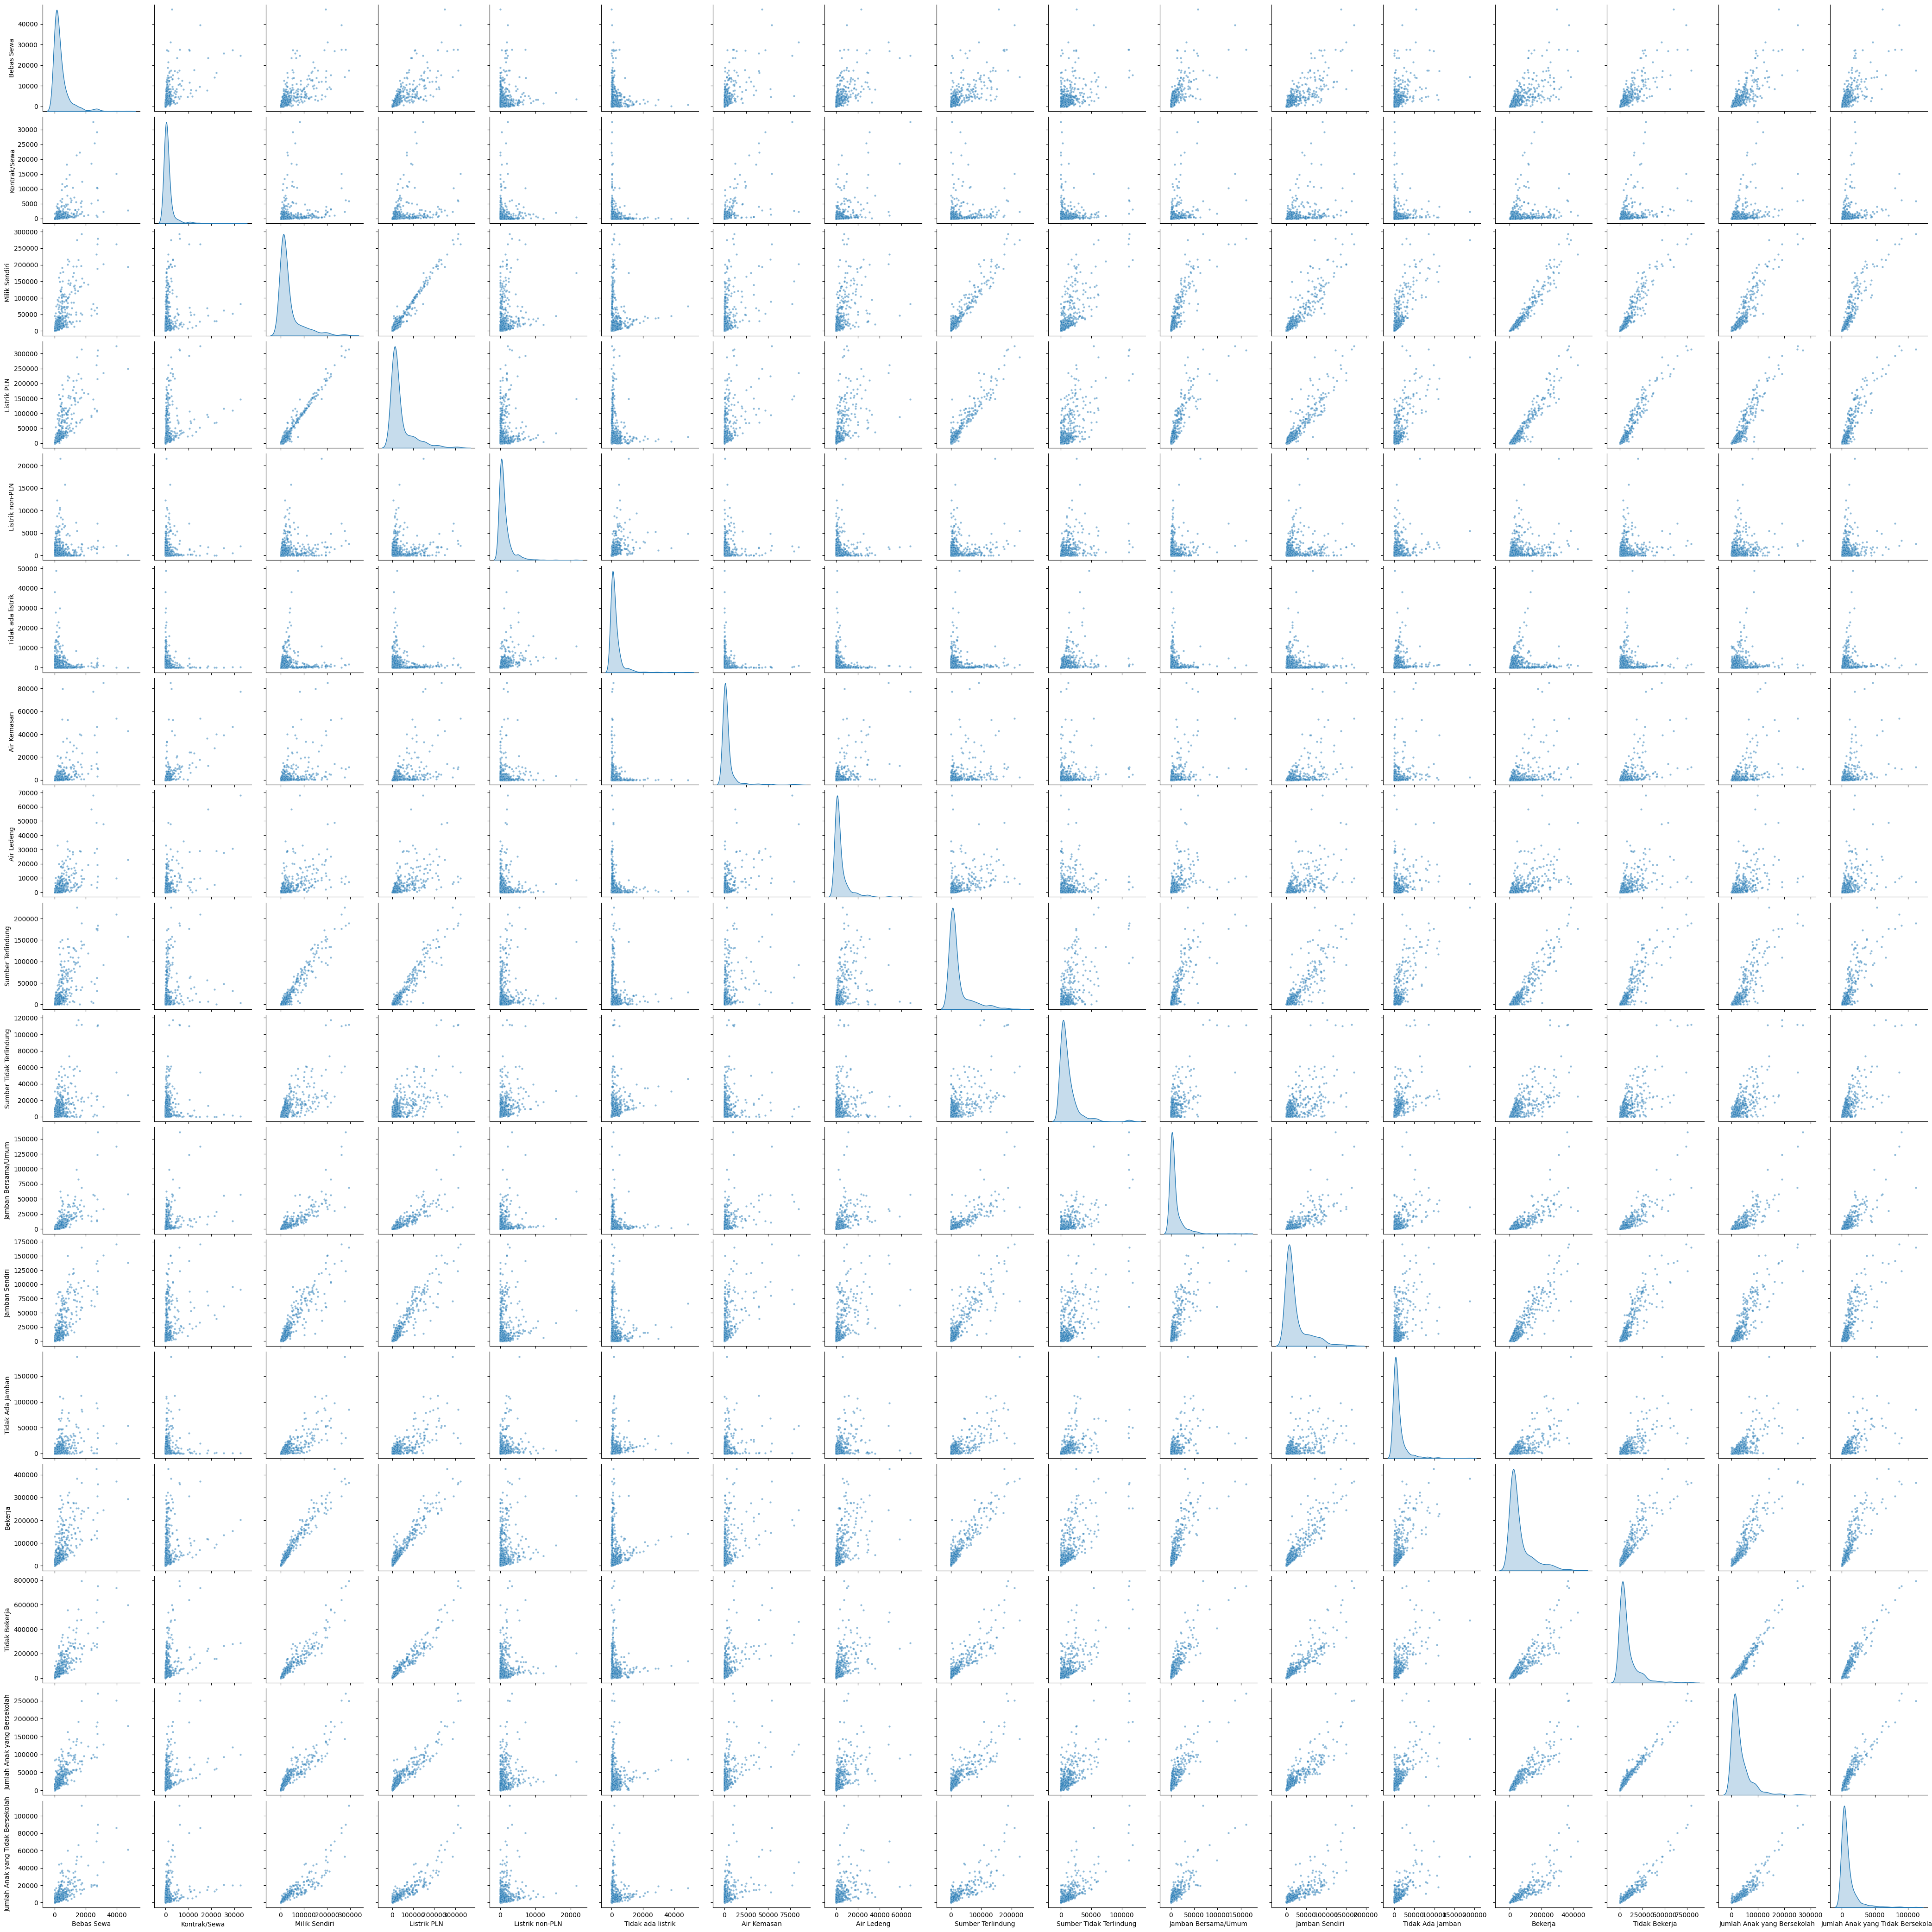

In [ ]:
features = ['Bebas Sewa', 'Kontrak/Sewa', 'Milik Sendiri', 'Listrik PLN',
            'Listrik non-PLN', 'Tidak ada listrik', 'Air Kemasan',
            'Air Ledeng', 'Sumber Terlindung', 'Sumber Tidak Terlindung',
            'Jamban Bersama/Umum', 'Jamban Sendiri', 'Tidak Ada Jamban', 'Bekerja',
            'Tidak Bekerja', 'Jumlah Anak yang Bersekolah', 'Jumlah Anak yang Tidak Bersekolah']

# Memfilter hanya fitur yang dipilih
data_final_selected = data_final[features]

# Membuat pair plot menggunakan seaborn
sns.pairplot(data_final_selected, diag_kind='kde', plot_kws={'alpha':0.5, 's':10})
plt.show()

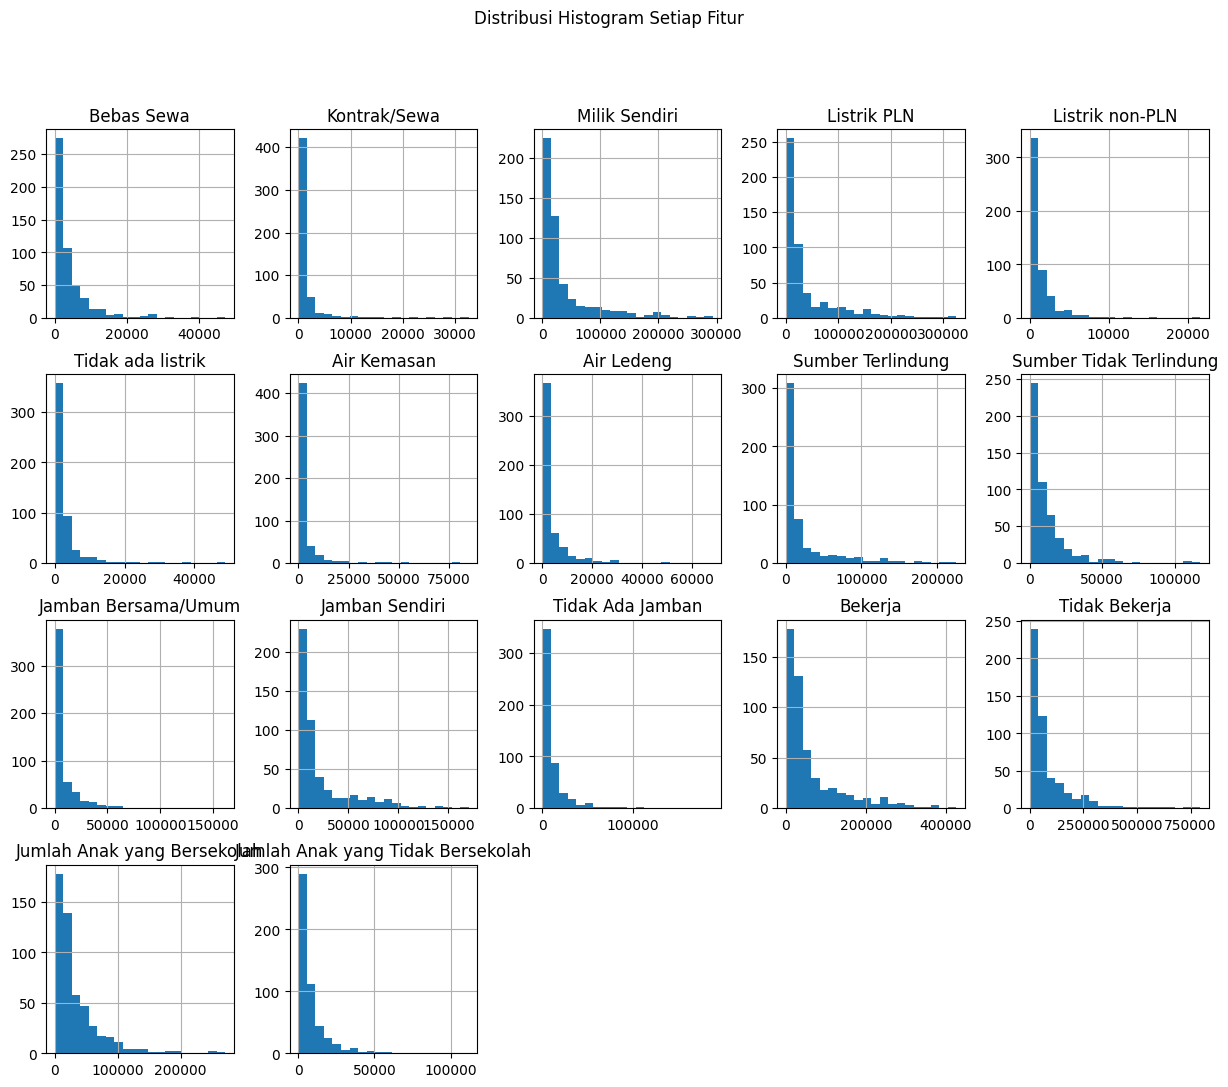

In [ ]:
data_final_selected.hist(bins=20, figsize=(15, 12), layout=(4, 5))
plt.suptitle("Distribusi Histogram Setiap Fitur")
plt.show()

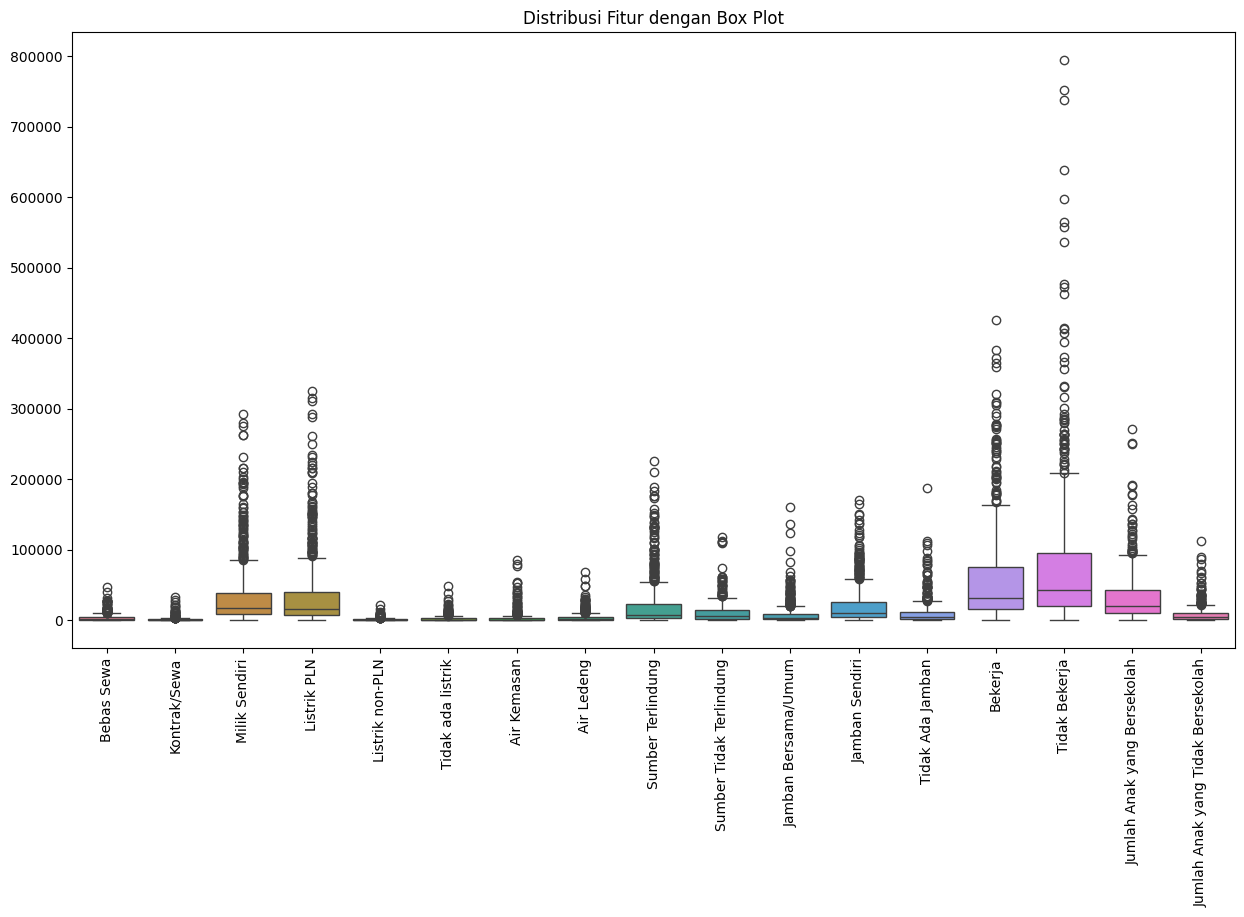

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=data_final_selected)
plt.xticks(rotation=90)
plt.title("Distribusi Fitur dengan Box Plot")
plt.show()

# 4. Membuat Label (Clustering) dengan KMeans

### 4.1 Menggunakan Kuartil

In [ ]:
# Copy Data
data_final_kuartil = data_final.copy()
data_final_kuartil

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,Sumber Terlindung,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
0,ACEH,ACEH BARAT,1177,338,18270,18835,125,982,1904,313,10073,7652,1464,8719,9759,31848,38077,16550,2867
1,ACEH,ACEH BARAT DAYA,2097,570,15359,17414,125,534,947,347,12419,4360,5215,3087,9771,23497,48534,18151,3445
2,ACEH,ACEH BESAR,3887,971,34134,38484,202,825,11310,2014,21377,4810,6803,24440,8268,51263,90972,37828,5580
3,ACEH,ACEH JAYA,684,68,7178,7752,21,179,470,219,4923,2340,1785,3392,2775,12924,15610,7688,1170
4,ACEH,ACEH SELATAN,3304,766,25008,27762,200,1433,1135,812,16574,10874,2627,9889,16879,35839,70932,27316,4920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873,40375,417,1818,490,8541,27102,6477,2838,26606,13166,67939,84736,47650,7579
543,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625,15034,1203,3837,106,340,8012,11616,12132,2112,5830,35756,35060,22869,4407
544,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690,25424,889,3374,684,2011,9814,17178,2025,6375,21287,54921,65013,42936,7600
545,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502,23512,549,1977,4,1431,15413,9190,2966,12302,10770,63399,37950,38143,3235


In [ ]:
# Membuat skor kemiskinan berdasarkan fitur yang tersedia
# Aturan skoring diatur sesuai asumsi pengaruh setiap fitur terhadap kemiskinan
data_final_kuartil['Skor Kemiskinan'] = (
    (data_final_kuartil['Bebas Sewa'] * 2) +                        # Skor tinggi untuk keluarga tanpa akses listrik
    (data_final_kuartil['Kontrak/Sewa'] * 3) +                      # Skor sedang untuk keluarga dengan listrik non-PLN
    (data_final_kuartil['Milik Sendiri'] * 1) +                     # Skor tinggi untuk air tidak terlindung
    (data_final_kuartil['Listrik PLN'] * 1) +                       # Skor tinggi untuk tanpa jamban
    (data_final_kuartil['Listrik non-PLN'] * 2) +                   # Skor sedang untuk tidak bekerja
    (data_final_kuartil['Tidak ada listrik'] * 3) +                 # Skor sedang untuk rumah tanpa sewa
    (data_final_kuartil['Air Kemasan'] * 1) +                        # Skor tinggi untuk anak yang tidak bersekolah
    (data_final_kuartil['Air Ledeng'] * 2) +                        # Skor tinggi untuk keluarga tanpa akses listrik
    (data_final_kuartil['Sumber Terlindung'] * 3) +                 # Skor sedang untuk keluarga dengan listrik non-PLN
    (data_final_kuartil['Sumber Tidak Terlindung'] * 4) +           # Skor tinggi untuk air tidak terlindung
    (data_final_kuartil['Jamban Bersama/Umum'] * 2) +               # Skor tinggi untuk tanpa jamban
    (data_final_kuartil['Jamban Sendiri'] * 1) +                    # Skor sedang untuk tidak bekerja
    (data_final_kuartil['Tidak Ada Jamban'] * 3) +                  # Skor sedang untuk rumah tanpa sewa
    (data_final_kuartil['Bekerja'] * 1) +                            # Skor tinggi untuk anak yang tidak bersekolah
    (data_final_kuartil['Tidak Bekerja'] * 2) +                     # Skor sedang untuk tidak bekerja
    (data_final_kuartil['Jumlah Anak yang Bersekolah'] * 1) +       # Skor sedang untuk rumah tanpa sewa
    (data_final_kuartil['Jumlah Anak yang Tidak Bersekolah'] * 2)   # Skor tinggi untuk anak yang tidak bersekolah
)

In [ ]:
# Menghitung kuartil
Q1 = data_final_kuartil['Skor Kemiskinan'].quantile(0.25)
Q2 = data_final_kuartil['Skor Kemiskinan'].quantile(0.50)
Q3 = data_final_kuartil['Skor Kemiskinan'].quantile(0.75)

In [ ]:
# Membuat kategori berdasarkan kuartil
def kategori_kemiskinan(skor):
    if skor <= Q1:
        return 'Sangat Miskin'  # Kuartil 1
    elif skor <= Q2:
        return 'Miskin'  # Kuartil 2
    else:
        return 'Menengah'  # Kuartil 3

# Menambahkan kolom kategori
data_final_kuartil['Kategori Kemiskinan'] = data_final_kuartil['Skor Kemiskinan'].apply(kategori_kemiskinan)

In [ ]:
# Menghitung jumlah data per kategori
jumlah_per_kuartil = data_final_kuartil['Kategori Kemiskinan'].value_counts()

# Menampilkan hasil
print(jumlah_per_kuartil)

Kategori Kemiskinan
Menengah         257
Sangat Miskin    129
Miskin           128
Name: count, dtype: int64


In [ ]:
data_final_kuartil

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,...,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah,Skor Kemiskinan,Kategori Kemiskinan
0,ACEH,ACEH BARAT,1177,338,18270,18835,125,982,1904,313,...,7652,1464,8719,9759,31848,38077,16550,2867,278236,Miskin
1,ACEH,ACEH BARAT DAYA,2097,570,15359,17414,125,534,947,347,...,4360,5215,3087,9771,23497,48534,18151,3445,285303,Miskin
2,ACEH,ACEH BESAR,3887,971,34134,38484,202,825,11310,2014,...,4810,6803,24440,8268,51263,90972,37828,5580,529938,Menengah
3,ACEH,ACEH JAYA,684,68,7178,7752,21,179,470,219,...,2340,1785,3392,2775,12924,15610,7688,1170,111577,Sangat Miskin
4,ACEH,ACEH SELATAN,3304,766,25008,27762,200,1433,1135,812,...,10874,2627,9889,16879,35839,70932,27316,4920,442991,Menengah
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873,40375,417,1818,490,8541,...,6477,2838,26606,13166,67939,84736,47650,7579,600653,Menengah
543,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625,15034,1203,3837,106,340,...,11616,12132,2112,5830,35756,35060,22869,4407,310005,Menengah
544,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690,25424,889,3374,684,2011,...,17178,2025,6375,21287,54921,65013,42936,7600,498585,Menengah
545,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502,23512,549,1977,4,1431,...,9190,2966,12302,10770,63399,37950,38143,3235,384055,Menengah


### 4.2 Menggunakan Clustering Kmeans

In [ ]:
# Copy Data
data_final_cluster = data_final.copy()
data_final_cluster

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,Sumber Terlindung,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah
0,ACEH,ACEH BARAT,1177,338,18270,18835,125,982,1904,313,10073,7652,1464,8719,9759,31848,38077,16550,2867
1,ACEH,ACEH BARAT DAYA,2097,570,15359,17414,125,534,947,347,12419,4360,5215,3087,9771,23497,48534,18151,3445
2,ACEH,ACEH BESAR,3887,971,34134,38484,202,825,11310,2014,21377,4810,6803,24440,8268,51263,90972,37828,5580
3,ACEH,ACEH JAYA,684,68,7178,7752,21,179,470,219,4923,2340,1785,3392,2775,12924,15610,7688,1170
4,ACEH,ACEH SELATAN,3304,766,25008,27762,200,1433,1135,812,16574,10874,2627,9889,16879,35839,70932,27316,4920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873,40375,417,1818,490,8541,27102,6477,2838,26606,13166,67939,84736,47650,7579
543,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625,15034,1203,3837,106,340,8012,11616,12132,2112,5830,35756,35060,22869,4407
544,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690,25424,889,3374,684,2011,9814,17178,2025,6375,21287,54921,65013,42936,7600
545,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502,23512,549,1977,4,1431,15413,9190,2966,12302,10770,63399,37950,38143,3235


In [ ]:
# Menyiapkan fitur yang digunakan untuk clustering
# Pastikan data sudah numerik dan lakukan preprocessing jika perlu
features = data_final_cluster[['Bebas Sewa', 'Kontrak/Sewa', 'Milik Sendiri', 'Listrik PLN', 'Listrik non-PLN', 'Tidak ada listrik',
               'Air Kemasan', 'Air Ledeng', 'Sumber Terlindung', 'Sumber Tidak Terlindung', 'Jamban Bersama/Umum',
               'Jamban Sendiri', 'Tidak Ada Jamban', 'Bekerja', 'Tidak Bekerja', 'Jumlah Anak yang Bersekolah', 'Jumlah Anak yang Tidak Bersekolah']]

In [ ]:
# Normalisasi data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled

array([[-0.50695845, -0.29992435, -0.37469071, ..., -0.41501491,
        -0.4419806 , -0.4836692 ],
       [-0.34272246, -0.23168843, -0.43237731, ..., -0.32076168,
        -0.39825471, -0.43750525],
       [-0.02317635, -0.11374618, -0.0603176 , ...,  0.06174942,
         0.13915591, -0.26698616],
       ...,
       [ 0.24388565,  0.53949509, -0.32673415, ..., -0.1722297 ,
         0.27866364, -0.10565194],
       [ 0.27566175,  0.04860825, -0.38990999, ..., -0.41615962,
         0.14775907, -0.45427762],
       [-0.22115212, -0.16786432, -0.64374289, ..., -0.62190873,
        -0.46688879, -0.60315237]])

In [ ]:
# Menentukan jumlah cluster, misalnya 4 kategori status kemiskinan
kmeans = KMeans(n_clusters=3, random_state=42)

In [ ]:
# Melakukan clustering
data_final_cluster['Cluster'] = kmeans.fit_predict(features_scaled)

In [ ]:
# Menampilkan hasil clustering
print(data_final_cluster['Cluster'].value_counts())

Cluster
0    408
2     91
1     15
Name: count, dtype: int64


In [ ]:
# Menampilkan fitur yang paling berpengaruh pada setiap cluster
features_names = features.columns
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}:")
    feature_contributions = pd.DataFrame(center, index=features_names, columns=["Contribution"])
    feature_contributions = feature_contributions.sort_values(by="Contribution", ascending=False)
    print(feature_contributions.head())  # Menampilkan 5 fitur terpenting untuk cluster


Cluster 0:
                         Contribution
Tidak ada listrik            0.085919
Listrik non-PLN             -0.010405
Kontrak/Sewa                -0.175939
Air Kemasan                 -0.235442
Sumber Tidak Terlindung     -0.252875
Cluster 1:
                                   Contribution
Jumlah Anak yang Tidak Bersekolah      4.246224
Tidak Bekerja                          4.181749
Jumlah Anak yang Bersekolah            3.932581
Jamban Bersama/Umum                    3.834192
Listrik PLN                            3.811210
Cluster 2:
                   Contribution
Jamban Sendiri         1.400237
Bekerja                1.377622
Listrik PLN            1.297097
Sumber Terlindung      1.262302
Milik Sendiri          1.248870


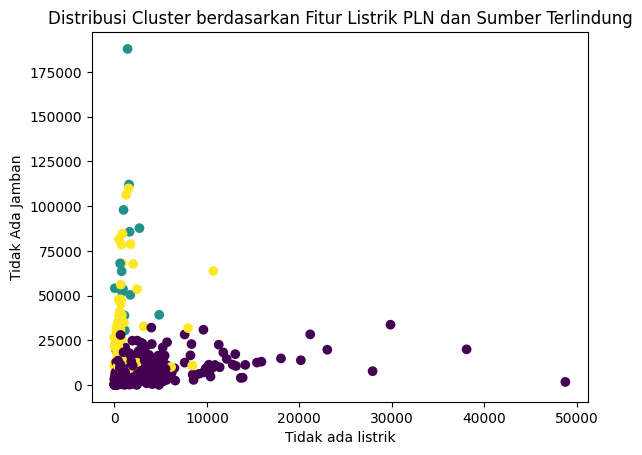

In [ ]:
# Visualisasi distribusi cluster berdasarkan dua fitur utama (contoh: 'Listrik PLN' vs 'Sumber Terlindung')
plt.scatter(data_final_cluster['Tidak ada listrik'], data_final_cluster['Tidak Ada Jamban'], c=data_final_cluster['Cluster'], cmap='viridis')
plt.xlabel('Tidak ada listrik')
plt.ylabel('Tidak Ada Jamban')
plt.title('Distribusi Cluster berdasarkan Fitur Listrik PLN dan Sumber Terlindung')
plt.show()

In [ ]:
# Menetapkan label berdasarkan cluster
# Anda bisa memberikan label berdasarkan analisis cluster atau centroid
def assign_label_to_cluster(cluster_id):
    if cluster_id == 0:
        return "Sangat Miskin"
    elif cluster_id == 1:
        return "Miskin"
    elif cluster_id == 2:
        return "Menengah"

In [ ]:
# Menerapkan label ke setiap cluster
data_final_cluster['Status Kemiskinan'] = data_final_cluster['Cluster'].apply(assign_label_to_cluster)

# Melihat hasil distribusi status kemiskinan
print(data_final_cluster['Status Kemiskinan'].value_counts())

Status Kemiskinan
Sangat Miskin    408
Menengah          91
Miskin            15
Name: count, dtype: int64


In [ ]:
data_final_cluster

,Provinsi,NamaKab/Kota,Bebas Sewa,Kontrak/Sewa,Milik Sendiri,Listrik PLN,Listrik non-PLN,Tidak ada listrik,Air Kemasan,Air Ledeng,...,Sumber Tidak Terlindung,Jamban Bersama/Umum,Jamban Sendiri,Tidak Ada Jamban,Bekerja,Tidak Bekerja,Jumlah Anak yang Bersekolah,Jumlah Anak yang Tidak Bersekolah,Cluster,Status Kemiskinan
0,ACEH,ACEH BARAT,1177,338,18270,18835,125,982,1904,313,...,7652,1464,8719,9759,31848,38077,16550,2867,0,Sangat Miskin
1,ACEH,ACEH BARAT DAYA,2097,570,15359,17414,125,534,947,347,...,4360,5215,3087,9771,23497,48534,18151,3445,0,Sangat Miskin
2,ACEH,ACEH BESAR,3887,971,34134,38484,202,825,11310,2014,...,4810,6803,24440,8268,51263,90972,37828,5580,0,Sangat Miskin
3,ACEH,ACEH JAYA,684,68,7178,7752,21,179,470,219,...,2340,1785,3392,2775,12924,15610,7688,1170,0,Sangat Miskin
4,ACEH,ACEH SELATAN,3304,766,25008,27762,200,1433,1135,812,...,10874,2627,9889,16879,35839,70932,27316,4920,0,Sangat Miskin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,SUMATERA UTARA,SIMALUNGUN,9621,3030,28873,40375,417,1818,490,8541,...,6477,2838,26606,13166,67939,84736,47650,7579,0,Sangat Miskin
543,SUMATERA UTARA,TAPANULI SELATAN,3384,2650,13625,15034,1203,3837,106,340,...,11616,12132,2112,5830,35756,35060,22869,4407,0,Sangat Miskin
544,SUMATERA UTARA,TAPANULI TENGAH,5383,3192,20690,25424,889,3374,684,2011,...,17178,2025,6375,21287,54921,65013,42936,7600,0,Sangat Miskin
545,SUMATERA UTARA,TAPANULI UTARA,5561,1523,17502,23512,549,1977,4,1431,...,9190,2966,12302,10770,63399,37950,38143,3235,0,Sangat Miskin


# 5. Modelling Dengan Random Forest Data Clustering

### 5.1 Splitting Data

In [ ]:
# Split data into features (X) and target (y)
X = data_final_cluster.drop(columns=['Provinsi', 'NamaKab/Kota', 'Cluster', 'Status Kemiskinan'])  # Sesuaikan nama kolom target
y = data_final_cluster['Status Kemiskinan']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 5.2 Random Forest With GridSearch

In [ ]:
# Initialize Random Forest Classifier
model_rf = RandomForestClassifier(random_state=42)

In [ ]:
# Set up parameters for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [ ]:
# Optimize hyperparameters with GridSearchCV
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [ ]:
# Best model after GridSearchCV
best_rf = grid_search.best_estimator_

# Train the model on training data
best_rf.fit(X_train, y_train)

# Predict on test data
y_pred = best_rf.predict(X_test)

In [ ]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 22   0   1]
 [  0   5   0]
 [  0   0 127]]


In [ ]:
# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

     Menengah       1.00      0.96      0.98        23
       Miskin       1.00      1.00      1.00         5
Sangat Miskin       0.99      1.00      1.00       127

     accuracy                           0.99       155
    macro avg       1.00      0.99      0.99       155
 weighted avg       0.99      0.99      0.99       155



### 5.3 Random Forest Maul

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Define the Random Forest Classifier with base hyperparameters
rf_classifier = RandomForestClassifier(n_estimators=100, min_samples_split=2, max_depth=None, min_samples_leaf=1)

# Train Random Forest using the base hyperparameters
rf_classifier.fit(X_train, y_train)

# Evaluating the model
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = rf_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-Score:", f1)

# Calculate precision, recall, and F1-score
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

# Calculate confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_mat)

Accuracy: 0.9935483870967742
F1-Score: 0.9934893527303393
Classification Report:
                precision    recall  f1-score   support

     Menengah       1.00      0.96      0.98        23
       Miskin       1.00      1.00      1.00         5
Sangat Miskin       0.99      1.00      1.00       127

     accuracy                           0.99       155
    macro avg       1.00      0.99      0.99       155
 weighted avg       0.99      0.99      0.99       155

Confusion Matrix:
 [[ 22   0   1]
 [  0   5   0]
 [  0   0 127]]


### 5.4 Random Forest Randomized Search

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [ ]:
random_search = RandomizedSearchCV(estimator=model_rf, param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# Best model after GridSearchCV
best_rf = random_search.best_estimator_

# Train the model on training data
best_rf.fit(X_train, y_train)

# Predict on test data
y_pred = best_rf.predict(X_test)

In [ ]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 22   0   1]
 [  0   5   0]
 [  0   0 127]]


In [ ]:
# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

     Menengah       1.00      0.96      0.98        23
       Miskin       1.00      1.00      1.00         5
Sangat Miskin       0.99      1.00      1.00       127

     accuracy                           0.99       155
    macro avg       1.00      0.99      0.99       155
 weighted avg       0.99      0.99      0.99       155



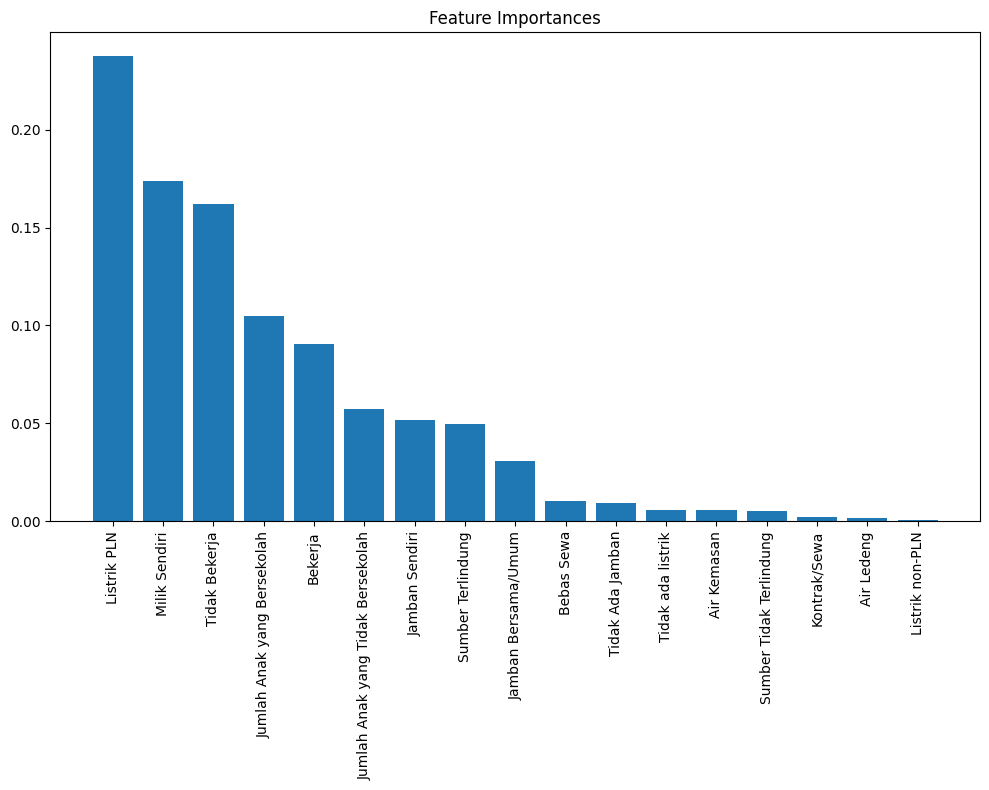

In [ ]:
# Optional: Display feature importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

# 6. Modelling Dengan Random Forest Data Kuartil

### 6.1 Splitting Data

In [ ]:
# Split data into features (X) and target (y)
X = data_final_kuartil.drop(columns=['Provinsi', 'NamaKab/Kota', 'Skor Kemiskinan', 'Kategori Kemiskinan'])  # Sesuaikan nama kolom target
y = data_final_kuartil['Kategori Kemiskinan']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6.2 Random Forest With GridSearch

In [ ]:
# Initialize Random Forest Classifier
model_rf = RandomForestClassifier(random_state=42)

In [ ]:
# Set up parameters for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [ ]:
# Optimize hyperparameters with GridSearchCV
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [ ]:
# Best model after GridSearchCV
best_rf = grid_search.best_estimator_

# Train the model on training data
best_rf.fit(X_train, y_train)

# Predict on test data
y_pred = best_rf.predict(X_test)

In [ ]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[55  1  0]
 [ 1 22  0]
 [ 0  1 23]]


In [ ]:
# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

     Menengah       0.98      0.98      0.98        56
       Miskin       0.92      0.96      0.94        23
Sangat Miskin       1.00      0.96      0.98        24

     accuracy                           0.97       103
    macro avg       0.97      0.97      0.97       103
 weighted avg       0.97      0.97      0.97       103



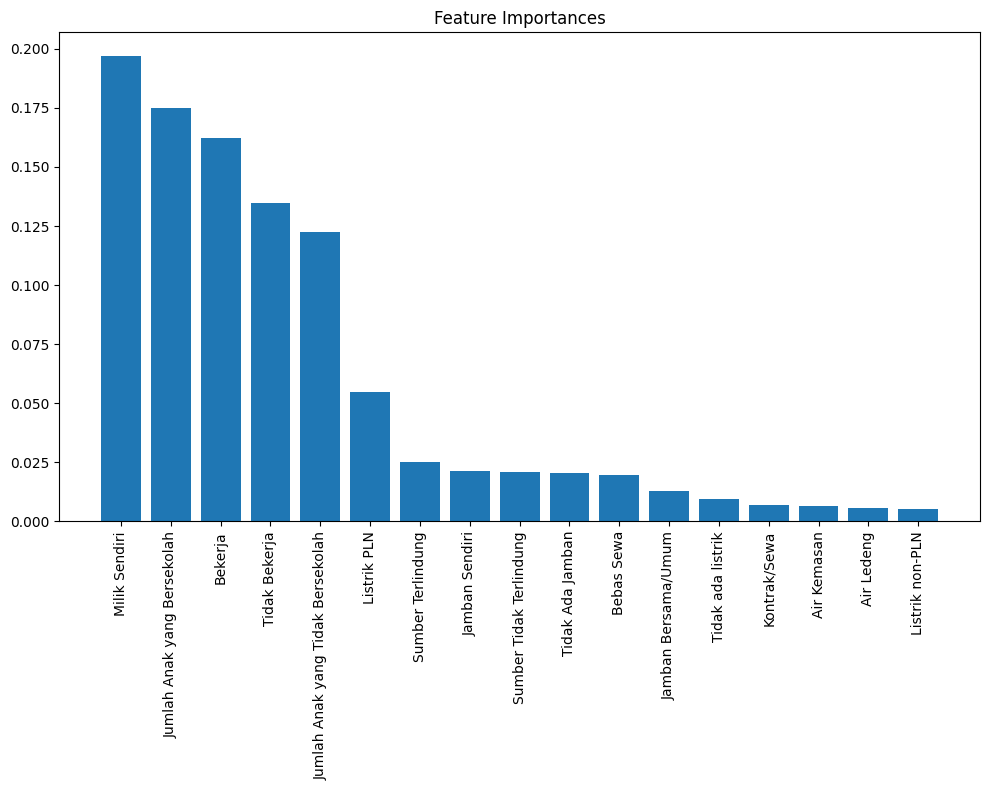

In [ ]:
# Optional: Display feature importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

### 6.3 Random Forest Maul

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Define the Random Forest Classifier with base hyperparameters
rf_classifier = RandomForestClassifier(n_estimators=100, min_samples_split=2, max_depth=None, min_samples_leaf=1)

# Train Random Forest using the base hyperparameters
rf_classifier.fit(X_train, y_train)

# Evaluating the model
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = rf_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-Score:", f1)

# Calculate precision, recall, and F1-score
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

# Calculate confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_mat)

Accuracy: 0.9805825242718447
F1-Score: 0.9805825242718447
Classification Report:
                precision    recall  f1-score   support

     Menengah       0.98      0.98      0.98        56
       Miskin       0.96      0.96      0.96        23
Sangat Miskin       1.00      1.00      1.00        24

     accuracy                           0.98       103
    macro avg       0.98      0.98      0.98       103
 weighted avg       0.98      0.98      0.98       103

Confusion Matrix:
 [[55  1  0]
 [ 1 22  0]
 [ 0  0 24]]


### 6.4 Random Forest Randomized Search

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [ ]:
random_search = RandomizedSearchCV(estimator=model_rf, param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# Best model after random_search
best_rf = random_search.best_estimator_

# Train the model on training data
best_rf.fit(X_train, y_train)

# Predict on test data
y_pred = best_rf.predict(X_test)

In [ ]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[55  1  0]
 [ 1 22  0]
 [ 0  1 23]]


In [ ]:
# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

     Menengah       0.98      0.98      0.98        56
       Miskin       0.92      0.96      0.94        23
Sangat Miskin       1.00      0.96      0.98        24

     accuracy                           0.97       103
    macro avg       0.97      0.97      0.97       103
 weighted avg       0.97      0.97      0.97       103



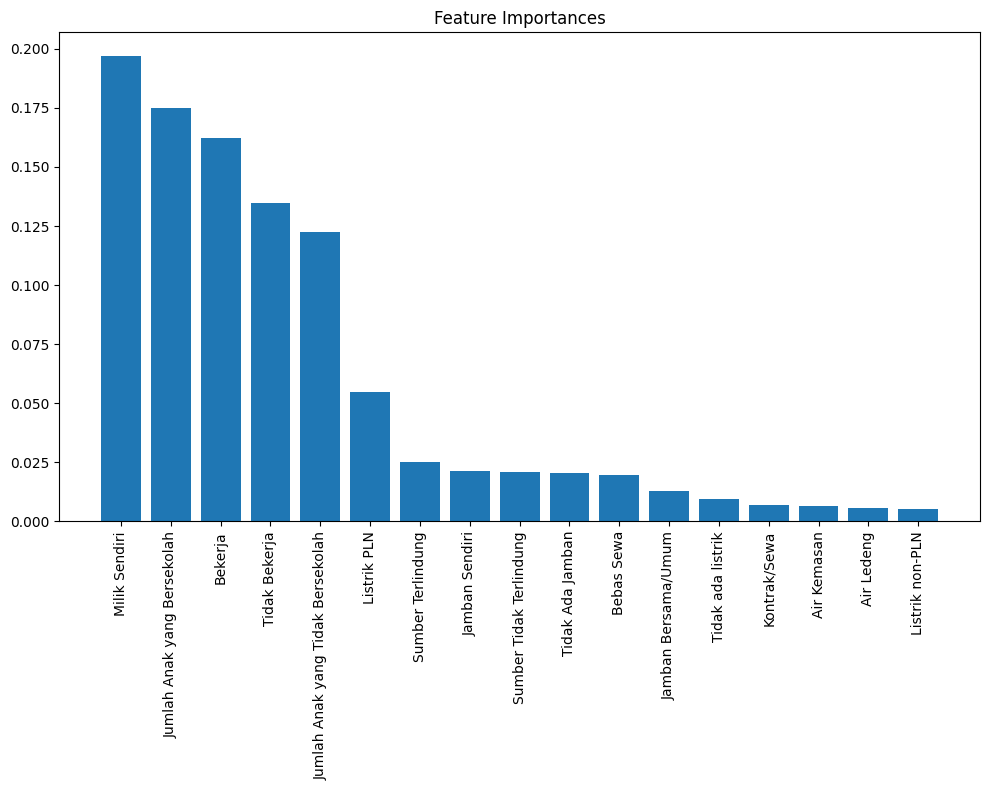

In [ ]:
# Optional: Display feature importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

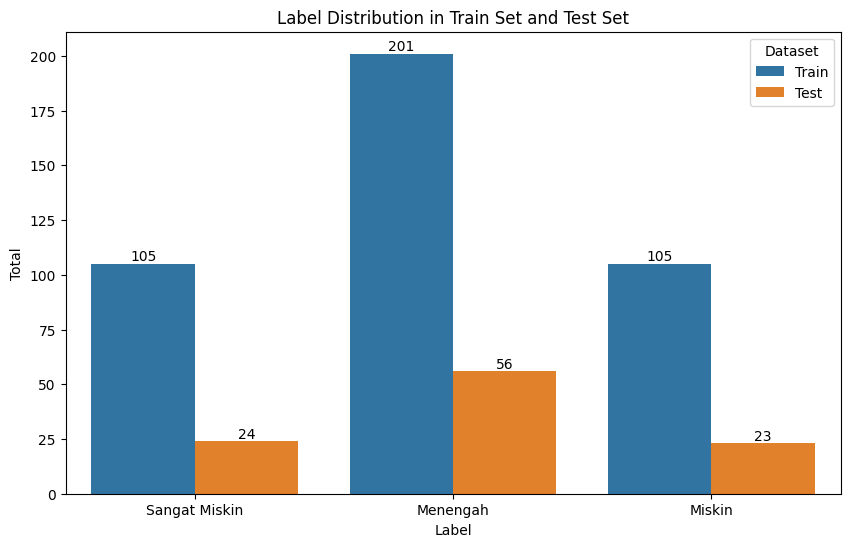

In [ ]:
# Membuat DataFrame baru untuk menyimpan label train dan test
train_labels = pd.DataFrame(y_train, columns=['Kategori Kemiskinan'])
train_labels['Set'] = 'Train'

test_labels = pd.DataFrame(y_test, columns=['Kategori Kemiskinan'])
test_labels['Set'] = 'Test'

# Menggabungkan data train dan test untuk plot
labels = pd.concat([train_labels, test_labels])

# Plot jumlah label menggunakan count plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=labels, x='Kategori Kemiskinan', hue='Set')
plt.title("Label Distribution in Train Set and Test Set")
plt.xlabel("Label")
plt.ylabel("Total")
plt.legend(title='Dataset')

# Menambahkan jumlah total di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.show()

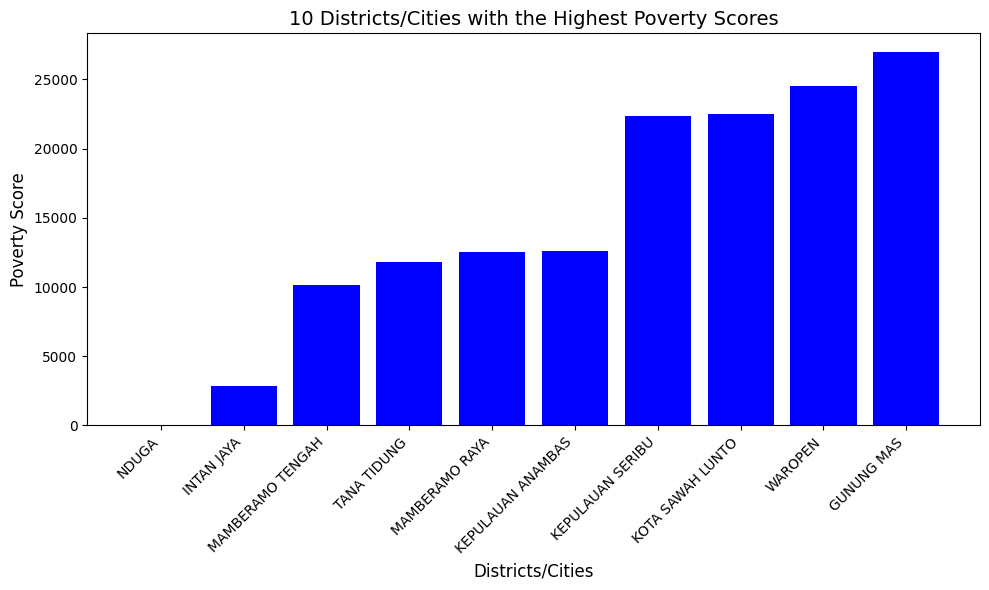

In [ ]:
df_sorted = data_final_kuartil.sort_values(by='Skor Kemiskinan', ascending=True)

# Memilih 10 kabupaten/kota dengan skor kemiskinan tertinggi
top_miskin = df_sorted[['NamaKab/Kota', 'Skor Kemiskinan']].head(10)

# Membuat plot
plt.figure(figsize=(10, 6))  # Mengatur ukuran plot
plt.bar(top_miskin['NamaKab/Kota'], top_miskin['Skor Kemiskinan'], color='blue')

# Menambahkan judul dan label
plt.title('10 Districts/Cities with the Highest Poverty Scores', fontsize=14)
plt.xlabel('Districts/Cities', fontsize=12)
plt.ylabel('Poverty Score', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Memiringkan label sumbu x agar lebih terbaca

# Menampilkan plot
plt.tight_layout()
plt.show()

In [ ]:

# Menampilkan kabupaten/kota dengan skor kemiskinan tertinggi
top_miskin = df_sorted[['NamaKab/Kota', 'Skor Kemiskinan']].head(10)# Menampilkan 10 teratas
print(top_miskin)

          NamaKab/Kota  Skor Kemiskinan
357              NDUGA                0
344         INTAN JAYA             2838
352   MAMBERAMO TENGAH            10132
248        TANA TIDUNG            11791
351     MAMBERAMO RAYA            12564
260  KEPULAUAN ANAMBAS            12612
60    KEPULAUAN SERIBU            22348
484   KOTA SAWAH LUNTO            22489
366            WAROPEN            24530
221         GUNUNG MAS            26977


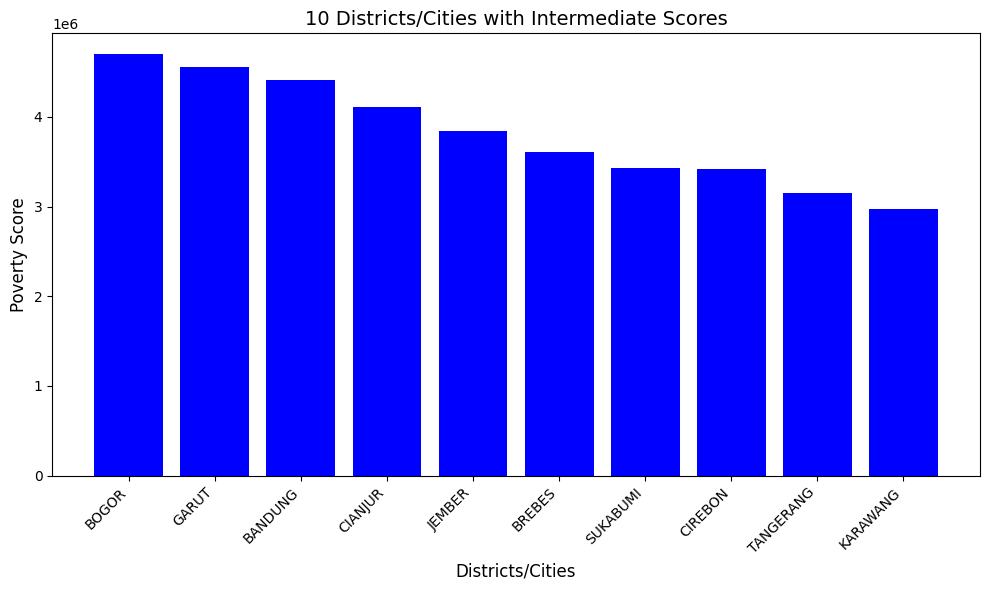

In [ ]:
df_sorted = data_final_kuartil.sort_values(by='Skor Kemiskinan', ascending=False)

# Memilih 10 kabupaten/kota dengan skor kemiskinan tertinggi
top_miskin = df_sorted[['NamaKab/Kota', 'Skor Kemiskinan']].head(10)

# Membuat plot
plt.figure(figsize=(10, 6))  # Mengatur ukuran plot
plt.bar(top_miskin['NamaKab/Kota'], top_miskin['Skor Kemiskinan'], color='blue')

# Menambahkan judul dan label
plt.title('10 Districts/Cities with Intermediate Scores', fontsize=14)
plt.xlabel('Districts/Cities', fontsize=12)
plt.ylabel('Poverty Score', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Memiringkan label sumbu x agar lebih terbaca

# Menampilkan plot
plt.tight_layout()
plt.show()

In [ ]:
# Menampilkan kabupaten/kota dengan skor kemiskinan tertinggi
top_miskin = df_sorted[['NamaKab/Kota', 'Skor Kemiskinan']].head(10)# Menampilkan 10 teratas
print(top_miskin)

    NamaKab/Kota  Skor Kemiskinan
89         BOGOR          4695464
93         GARUT          4553570
86       BANDUNG          4406973
91       CIANJUR          4106238
156       JEMBER          3837458
119       BREBES          3604938
110     SUKABUMI          3431817
92       CIREBON          3419179
41     TANGERANG          3152294
95      KARAWANG          2972120
